# Track B EDA - IMA 기반 고위험 지역 분류

In [ ]:
# ── 패키지 설치 (Colab 최초 1회) ─────────────────────────────
!pip install statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ───────────────────────────────────────────
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
import os, matplotlib.font_manager as fm
cache_dir = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir):
    [os.remove(os.path.join(cache_dir, f)) for f in os.listdir(cache_dir)]

import IPython
IPython.Application.instance().kernel.do_shutdown(True)  # 런타임 재시작

{'status': 'ok', 'restart': True}

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ──────────────────────────────────────────────
# df_analysis_v3_1 : 피처 데이터 (420행 × 26열)
# df_criteria      : IMD 기반 위험등급 라벨 (420행 × 13열)
# from google.colab import drive
# drive.mount('/content/drive')

df   = pd.read_csv('/content/drive/MyDrive/Datasets/BP2 data/df_analysis_v3 (1).csv')
dc   = pd.read_csv('/content/drive/MyDrive/Datasets/BP2 data/df_criteria.csv')

# ── 두 파일 병합 ─────────────────────────────────────────────
# 행정동코드(10자리) 기준 inner join → 420개 행정동 완전 일치
merged = pd.merge(
    df,
    dc[['행정동코드', '위험등급', 'IMD_score',
        'D1_수급자비율', 'D2_시설부족', 'D3_미충족의료율', 'D4_수급비율(2024)']],
    on='행정동코드', how='inner'
)

# ── 분석 전반에 사용할 피처 목록 ─────────────────────────────
# 제외 근거:
#   인구_60대/70대/80세이상 → 서로 r=0.87~0.97, 인프라갭과도 스케일 혼용
#   비율_65-69세/70대/80세이상 → 합산 시 100%에 수렴 (완전 선형 종속)
#   연령가중수요지수 → 비율_80세이상과 r=0.976, VIF=173,814
#   취약도지수 → Y라벨 생성 재료와 동일 (자명성 문제)
#   독거노인수_2018, 행정동명_norm → 참조값/병합키, 피처 아님
FEATURES = ['고령화율', '독거노인비율', '의료기관수', '포화도',
            '시설수', '인프라갭', '고령화율_변화']

print(f"병합 완료: {merged.shape[0]}행 × {merged.shape[1]}열")
print(f"위험등급 분포:\n{merged['위험등급'].value_counts().sort_index()}")

병합 완료: 420행 × 32열
위험등급 분포:
위험등급
고위험    140
저위험    140
중위험    140
Name: count, dtype: int64


## 1. 분석 개요

**분석 목적**: 서울시 420개 행정동을 고위험·중위험·저위험으로 분류하는 지도학습 모델 구축을 위한 사전 탐색

**Y 라벨**: IMD(Index of Multiple Deprivation) — 4개 박탈 지표의 가중합
- D1 소득박탈 (30%): 기초생활수급자수 / 65세이상인구
- D2 요양시설접근성 (25%): NHIS 장기요양기관수 / 65세이상인구
- D3 복지기반 (25%): 지역사회건강조사 미충족의료율
- D4 건강위험 (20%): 지역사회건강조사 수급비율(2024)

취약도지수를 Y로 쓰지 않는 이유: 취약도지수 = 고령화율 × 독거노인비율 / 100으로
X 피처의 선형 조합(R²=0.965)이어서 자명성 문제가 발생함.
IMD는 X 피처들과 독립적으로 구성됨 (D1~D4 간 최대 상관 0.238).

**X 피처**: 고령화율, 독거노인비율, 의료기관수, 포화도, 시설수, 인프라갭, 고령화율_변화

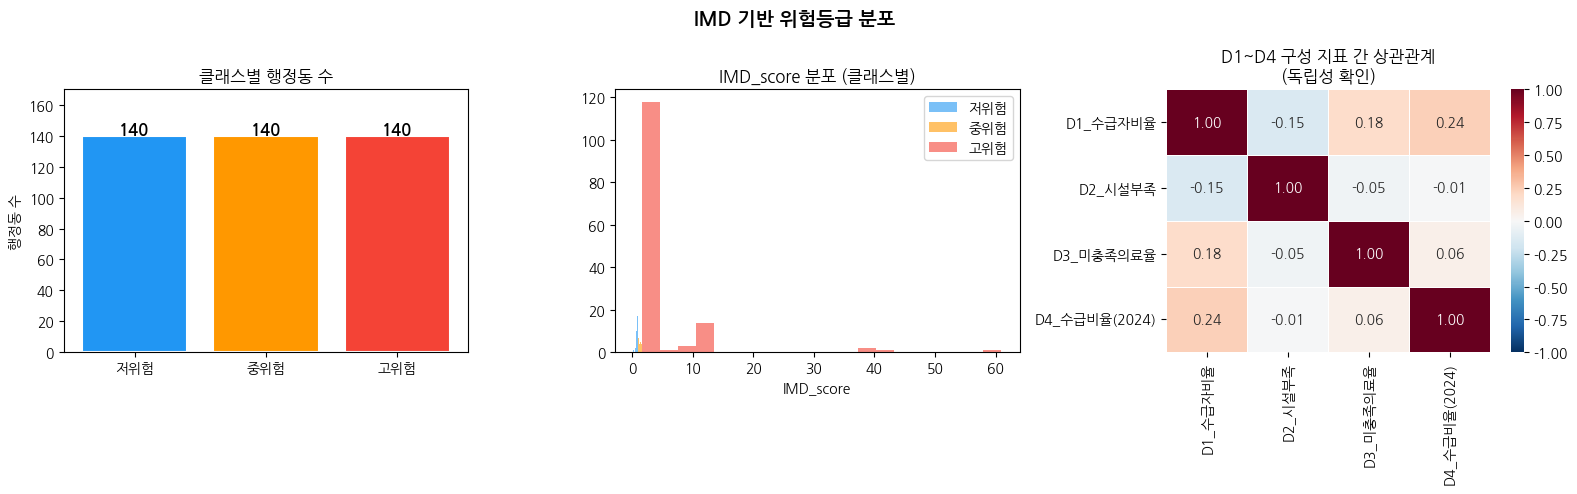

IMD_score 클래스별 분포
--------------------------------------------------
      count  mean   std   min   25%   50%   75%    max
위험등급                                                  
저위험   140.0  0.79  0.15  0.22  0.74  0.82  0.89   0.96
중위험   140.0  1.21  0.19  0.96  1.05  1.16  1.33   1.61
고위험   140.0  4.60  7.88  1.61  1.79  2.10  2.42  60.96

※ 고위험 클래스 이상값 26개 존재
  → 3분위 기반 라벨링이므로 이상값이 분류 결과를 왜곡하지 않음
  → 모델 학습 시 스케일링 전략 수립 필요


In [ ]:
# =============================================================
# IMD 구성 지표 및 위험등급 분포 확인
# -------------------------------------------------------------
# IMD는 Z-score 표준화 → exp 변환 → 가중합 방식으로 산출됨
# exp 변환은 지표 간 방향을 통일하고 음수를 제거하기 위함
# 3분위(33%/66%) 기준으로 저위험/중위험/고위험 140개씩 균등 분류
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('IMD 기반 위험등급 분포', fontsize=14, fontweight='bold')

colors = {'저위험': '#2196F3', '중위험': '#FF9800', '고위험': '#F44336'}
order  = ['저위험', '중위험', '고위험']
counts = merged['위험등급'].value_counts()

# 클래스 분포 막대
axes[0].bar(order, [counts[c] for c in order],
            color=[colors[c] for c in order], edgecolor='white', linewidth=1.5)
for i, c in enumerate(order):
    axes[0].text(i, counts[c] + 1, str(counts[c]),
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('클래스별 행정동 수')
axes[0].set_ylim(0, 170)
axes[0].set_ylabel('행정동 수')

# IMD_score 분포 (클래스별)
# 고위험 클래스의 IMD_score 분포가 매우 우편향 (최대 60.96) → 이상값 존재
for c in order:
    data = merged[merged['위험등급'] == c]['IMD_score']
    axes[1].hist(data, bins=20, alpha=0.6, label=c, color=colors[c])
axes[1].set_title('IMD_score 분포 (클래스별)')
axes[1].set_xlabel('IMD_score')
axes[1].legend()

# D1~D4 구성 지표 간 상관관계
# 지표 간 독립성이 확보되어야 IMD가 다차원 박탈을 제대로 측정함
d_cols = ['D1_수급자비율', 'D2_시설부족', 'D3_미충족의료율', 'D4_수급비율(2024)']
d_corr = merged[d_cols].corr()
sns.heatmap(d_corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[2],
            linewidths=0.5, annot_kws={'size': 10})
axes[2].set_title('D1~D4 구성 지표 간 상관관계\n(독립성 확인)')

plt.tight_layout()
plt.show()

# IMD_score 클래스별 요약
print("IMD_score 클래스별 분포")
print("-" * 50)
print(merged.groupby('위험등급')['IMD_score'].describe().round(2).loc[order])
print()
print(f"※ 고위험 클래스 이상값 {((merged['IMD_score'] > merged['IMD_score'].quantile(0.75) + 1.5*(merged['IMD_score'].quantile(0.75)-merged['IMD_score'].quantile(0.25)))).sum()}개 존재")
print("  → 3분위 기반 라벨링이므로 이상값이 분류 결과를 왜곡하지 않음")
print("  → 모델 학습 시 스케일링 전략 수립 필요")

## 2. X 피처 분포 분석

### 피처 선택 근거
다중공선성(VIF) 사전 검토를 통해 아래 피처를 제외하고 7개 피처만 사용한다.

| 제외 피처 | 제외 이유 |
|---|---|
| 인구_60대/70대/80세이상 | 상호 r=0.87~0.97, 절대 규모라 인프라갭과 스케일 혼용 |
| 비율_65-69세/70대/80세이상 | 합산 시 100% 수렴 → 완전 선형 종속 |
| 연령가중수요지수 | 비율_80세이상과 r=0.976, VIF=173,814 |
| 취약도지수 | Y 생성 재료(고령화율 × 독거노인비율)와 동일 → 자명성 |

단변수 분포에서 확인할 것:
- **왜도(skew)**: |skew| > 1.0이면 로그변환 검토 → 독거노인비율(2.00), 의료기관수(2.40) 해당
- **이상값**: IQR 1.5배 기준 이탈 → 전처리 단계 처리 방향 결정 근거
- **스케일 차이**: 인프라갭(41~7,688) vs 포화도(0.81~1.00) → 스케일링 필수

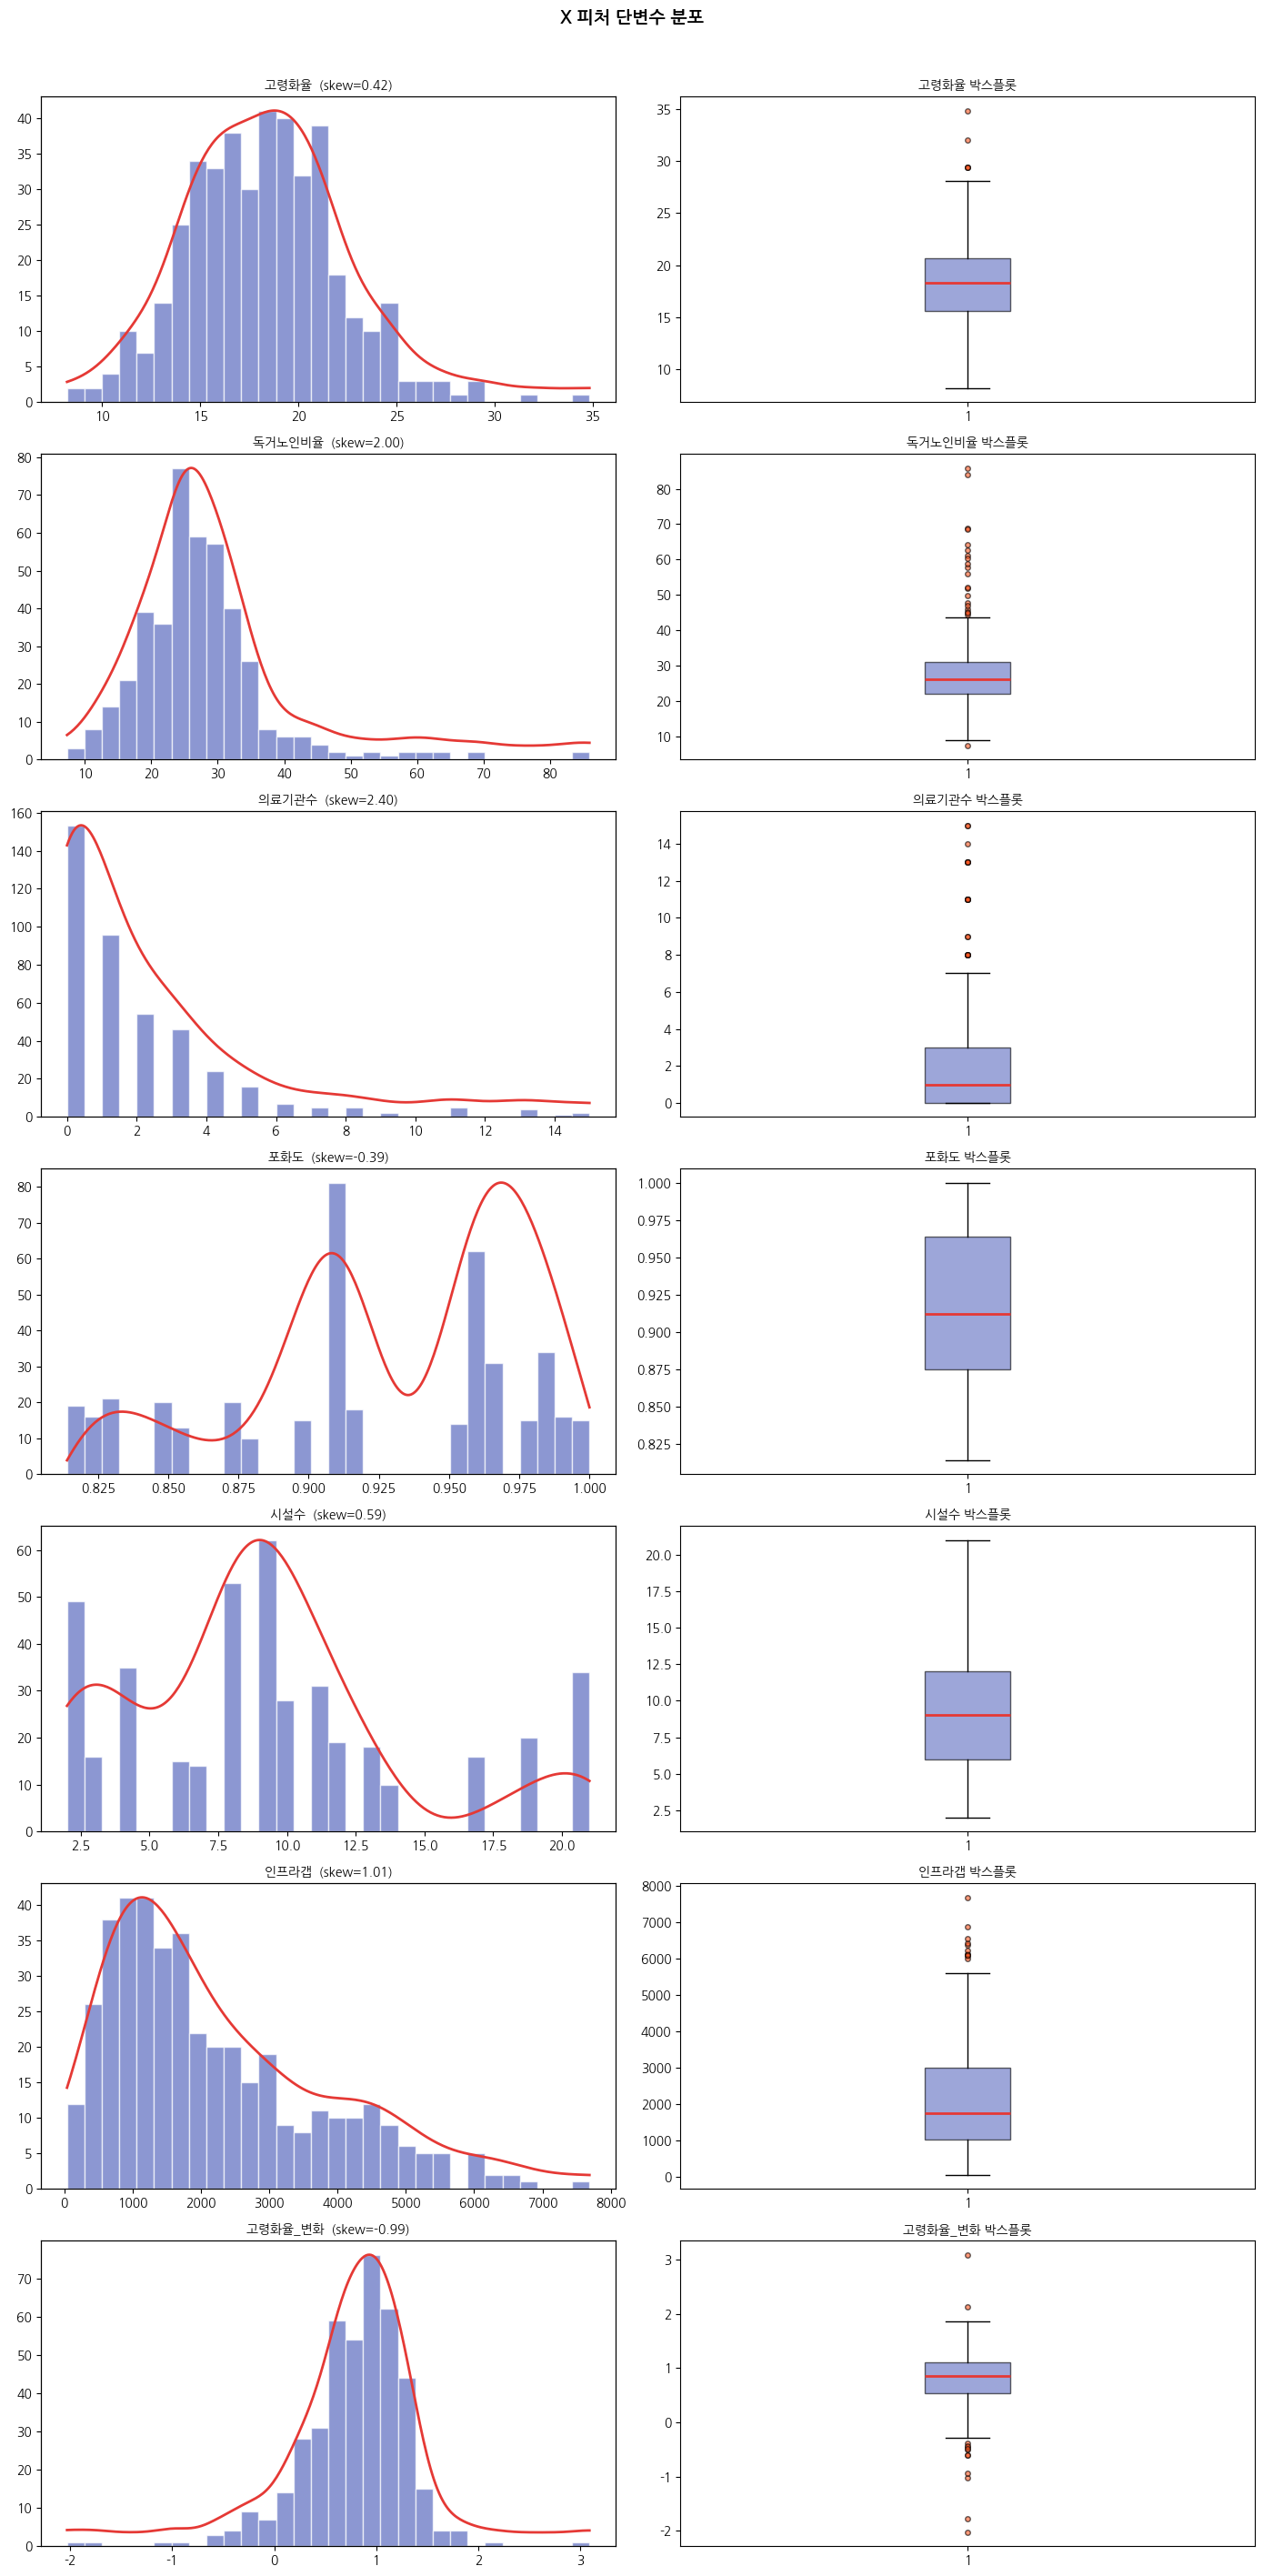

피처별 분포 요약
피처                  왜도    이상값수    비율(%)  비고
------------------------------------------------------------
고령화율             +0.42       5개     1.2%  
독거노인비율           +2.00      21개     5.0%  ← 로그변환 검토
의료기관수            +2.40      19개     4.5%  ← 로그변환 검토
포화도              -0.39       0개     0.0%  
시설수              +0.59       0개     0.0%  
인프라갭             +1.01      11개     2.6%  ← 로그변환 검토
고령화율_변화          -0.99      13개     3.1%  


In [ ]:
# =============================================================
# 피처별 단변수 분포 (히스토그램 + 박스플롯)
# =============================================================

fig, axes = plt.subplots(7, 2, figsize=(14, 28))
fig.suptitle('X 피처 단변수 분포', fontsize=14, fontweight='bold', y=1.01)

for i, feat in enumerate(FEATURES):
    # 히스토그램
    ax_h = axes[i][0]
    ax_h.hist(merged[feat], bins=30, color='#5C6BC0', alpha=0.7, edgecolor='white')
    # KDE 오버레이
    ax2 = ax_h.twinx()
    kde_x = np.linspace(merged[feat].min(), merged[feat].max(), 300)
    kde   = stats.gaussian_kde(merged[feat].dropna())
    ax2.plot(kde_x, kde(kde_x), color='#E53935', linewidth=2)
    ax2.set_yticks([])
    ax_h.set_title(f'{feat}  (skew={merged[feat].skew():.2f})', fontsize=10)

    # 박스플롯 — 이상값(점)의 위치와 양 파악
    ax_b = axes[i][1]
    ax_b.boxplot(merged[feat].dropna(), patch_artist=True,
                 boxprops=dict(facecolor='#5C6BC0', alpha=0.6),
                 medianprops=dict(color='#E53935', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor='#FF5722',
                                 markersize=4, alpha=0.6))
    ax_b.set_title(f'{feat} 박스플롯', fontsize=10)

plt.tight_layout()
plt.show()

# 왜도 + 이상값 수 요약
print("피처별 분포 요약")
print(f"{'피처':<15} {'왜도':>6}  {'이상값수':>6}  {'비율(%)':>7}  {'비고'}")
print("-" * 60)
for feat in FEATURES:
    skew = merged[feat].skew()
    Q1, Q3 = merged[feat].quantile(0.25), merged[feat].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((merged[feat] < Q1-1.5*IQR) | (merged[feat] > Q3+1.5*IQR)).sum()
    ratio  = n_out / len(merged) * 100
    note   = "← 로그변환 검토" if abs(skew) > 1.0 else ""
    print(f"{feat:<15} {skew:>+6.2f}  {n_out:>6}개  {ratio:>6.1f}%  {note}")

## 3. 이상값 및 스케일 점검

### 전처리 방향 결정을 위한 사전 확인
- 로그변환 전후 왜도 변화를 확인해 변환 효과를 검증한다
- 피처 간 스케일 차이는 거리 기반 모델(SVM, Logistic Regression)에서
  특정 피처가 결과를 지배하는 왜곡을 일으키므로, 스케일러 선택 근거를 확인한다
- 이상값이 많은 피처(비율 5% 초과)는 RobustScaler 선택 근거가 된다

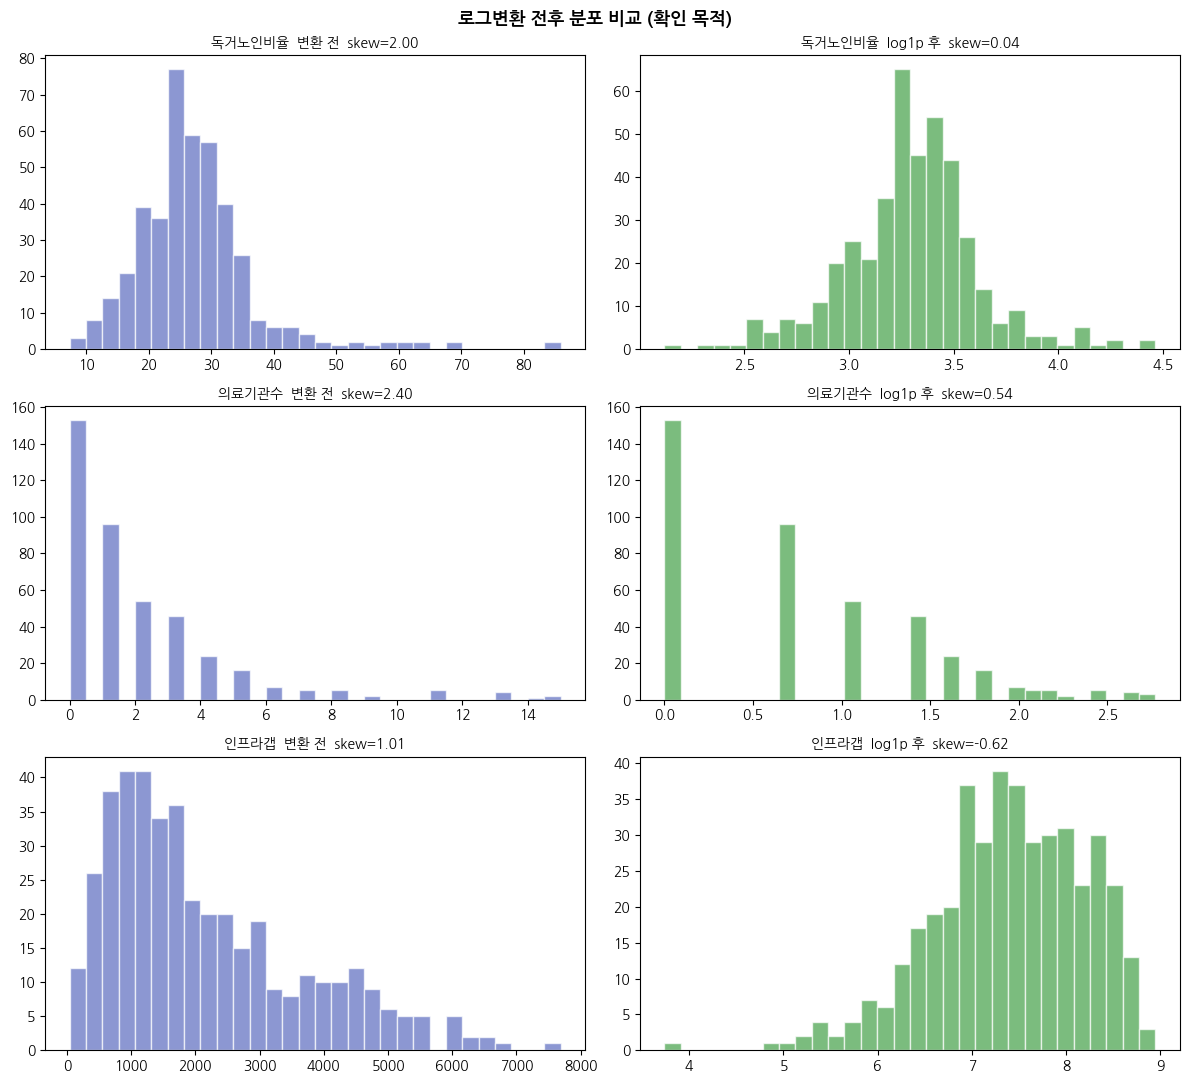

피처별 스케일 현황  (범위 큰 순)
피처                   최솟값      최댓값       범위     표준편차
-------------------------------------------------------
인프라갭               41.00  7688.00  7647.00  1514.80
독거노인비율              7.32    85.92    78.60     9.76
고령화율                8.21    34.83    26.62     3.85
시설수                 2.00    21.00    19.00     5.51
의료기관수               0.00    15.00    15.00     2.62
고령화율_변화            -2.03     3.09     5.12     0.51
포화도                 0.81     1.00     0.19     0.06

[ 스케일러 선택 근거 ]
  인프라갭 범위 7,647 vs 포화도 범위 0.19 → 스케일링 필수
  독거노인비율·의료기관수 이상값 多 → RobustScaler 우선 검토


In [ ]:
# =============================================================
# 이상값 현황 + 로그변환 전후 비교
# -------------------------------------------------------------
# 이 단계에서는 데이터를 직접 변환하지 않고 시각적·수치적 확인만 수행
# 실제 변환 적용은 전처리 단계에서 진행
# =============================================================

log_targets = ['독거노인비율', '의료기관수', '인프라갭']  # skew > 1.0

fig, axes = plt.subplots(3, 2, figsize=(12, 11))
fig.suptitle('로그변환 전후 분포 비교 (확인 목적)', fontsize=13, fontweight='bold')

for i, feat in enumerate(log_targets):
    original = merged[feat]
    log_vals = np.log1p(merged[feat])   # log(x+1): 0 포함 데이터에 안전

    axes[i][0].hist(original, bins=30, color='#5C6BC0', alpha=0.7, edgecolor='white')
    axes[i][0].set_title(f'{feat}  변환 전  skew={original.skew():.2f}', fontsize=10)

    axes[i][1].hist(log_vals, bins=30, color='#43A047', alpha=0.7, edgecolor='white')
    axes[i][1].set_title(f'{feat}  log1p 후  skew={log_vals.skew():.2f}', fontsize=10)

plt.tight_layout()
plt.show()

# 스케일 현황 비교
print("피처별 스케일 현황  (범위 큰 순)")
print(f"{'피처':<15} {'최솟값':>8} {'최댓값':>8} {'범위':>8} {'표준편차':>8}")
print("-" * 55)
scale_df = pd.DataFrame({
    '피처'    : FEATURES,
    '최솟값'  : [merged[f].min() for f in FEATURES],
    '최댓값'  : [merged[f].max() for f in FEATURES],
    '범위'    : [merged[f].max()-merged[f].min() for f in FEATURES],
    '표준편차': [merged[f].std() for f in FEATURES]
}).sort_values('범위', ascending=False)

for _, row in scale_df.iterrows():
    print(f"{row['피처']:<15} {row['최솟값']:>8.2f} {row['최댓값']:>8.2f} "
          f"{row['범위']:>8.2f} {row['표준편차']:>8.2f}")

print()
print("[ 스케일러 선택 근거 ]")
print("  인프라갭 범위 7,647 vs 포화도 범위 0.19 → 스케일링 필수")
print("  독거노인비율·의료기관수 이상값 多 → RobustScaler 우선 검토")

## 4. 상관관계 및 다중공선성 분석

피처 간 상관관계와 VIF를 통해 모델링 전 두 가지를 확인한다.

1. **Y와의 상관**: 어떤 피처가 위험등급 분류에 더 기여하는가
2. **피처 간 상관 / VIF**: 다중공선성 → 회귀 계수 불안정, 모델 해석 왜곡

VIF 판단 기준: < 5 정상 / 5~10 주의 / > 10 제거 권장

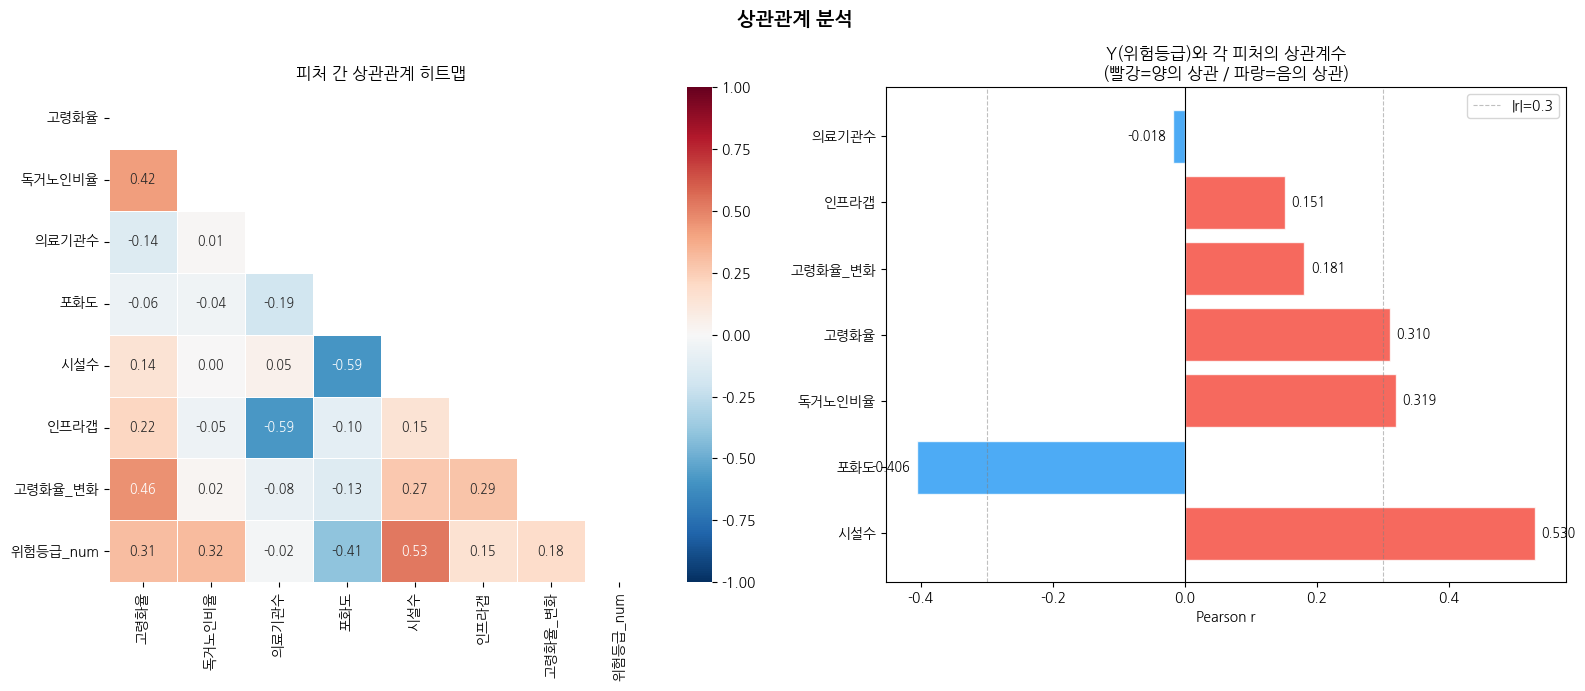

VIF (분산팽창인수)  |  기준: <5 정상 / 5~10 주의 / >10 제거 권장
--------------------------------------------------
  고령화율           :     38.2  ← 제거 권장
  포화도            :     24.5  ← 제거 권장
  독거노인비율         :     11.4  ← 제거 권장
  인프라갭           :      5.1  ← 주의
  고령화율_변화        :      4.9  ✓
  시설수            :      4.4  ✓
  의료기관수          :      2.3  ✓

※ VIF 제거 권장 판정이 나온 피처 중 고령화율(F=27.9), 독거노인비율(F=25.1)은
  ANOVA 기준 분류 핵심 피처임 → VIF만으로 제거 결정 불가
  → 전처리 단계에서 스케일링/변환 후 VIF 재계산 및 처리 방향 결정

※ 포화도 VIF=24.5는 시설수와의 구조적 연동(요양시설 포화도) 때문
  → 전처리 단계에서 포화도 제거 또는 시설수와 병합 검토 필요


In [ ]:
# =============================================================
# 상관관계 분석 + VIF 다중공선성 검사
# -------------------------------------------------------------
# 위험등급을 수치(저=0, 중=1, 고=2)로 변환해 피어슨 상관 계산
# 상관계수는 선형 관계만 측정 → 비선형 기여 피처는 낮게 나올 수 있음
# (ANOVA와 함께 해석해야 함)
# =============================================================

merged['위험등급_num'] = merged['위험등급'].map({'저위험':0,'중위험':1,'고위험':2})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('상관관계 분석', fontsize=14, fontweight='bold')

# 히트맵 (하삼각) — 대칭 행렬이므로 중복 제거
corr_cols   = FEATURES + ['위험등급_num']
corr_matrix = merged[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 9})
axes[0].set_title('피처 간 상관관계 히트맵')

# Y와의 상관계수 bar chart
corr_y     = corr_matrix['위험등급_num'].drop('위험등급_num').sort_values(key=abs, ascending=False)
colors_bar = ['#F44336' if v > 0 else '#2196F3' for v in corr_y.values]
axes[1].barh(corr_y.index, corr_y.values, color=colors_bar, alpha=0.8, edgecolor='white')
axes[1].axvline(0,    color='black', linewidth=0.8)
axes[1].axvline( 0.3, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5, label='|r|=0.3')
axes[1].axvline(-0.3, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
for i, (idx, v) in enumerate(corr_y.items()):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=9)
axes[1].set_title('Y(위험등급)와 각 피처의 상관계수\n(빨강=양의 상관 / 파랑=음의 상관)')
axes[1].set_xlabel('Pearson r')
axes[1].legend()

plt.tight_layout()
plt.show()

# VIF 계산
print("VIF (분산팽창인수)  |  기준: <5 정상 / 5~10 주의 / >10 제거 권장")
print("-" * 50)
vif_data = merged[FEATURES].dropna()
vif_df   = pd.DataFrame({
    '피처': FEATURES,
    'VIF' : [variance_inflation_factor(vif_data.values, i)
             for i in range(len(FEATURES))]
}).sort_values('VIF', ascending=False)

for _, row in vif_df.iterrows():
    flag = "  ← 제거 권장" if row['VIF'] > 10 else ("  ← 주의" if row['VIF'] > 5 else "  ✓")
    print(f"  {row['피처']:<15}: {row['VIF']:>8.1f}{flag}")

print()
print("※ VIF 제거 권장 판정이 나온 피처 중 고령화율(F=27.9), 독거노인비율(F=25.1)은")
print("  ANOVA 기준 분류 핵심 피처임 → VIF만으로 제거 결정 불가")
print("  → 전처리 단계에서 스케일링/변환 후 VIF 재계산 및 처리 방향 결정")
print()
print("※ 포화도 VIF=24.5는 시설수와의 구조적 연동(요양시설 포화도) 때문")
print("  → 전처리 단계에서 포화도 제거 또는 시설수와 병합 검토 필요")

## 5. 클래스별 피처 분포 비교

박스플롯으로 위험등급에 따라 피처값이 실제로 달라지는지 확인하고,
ANOVA로 클래스 간 차이가 통계적으로 유의미한지 검증한다.

- **박스 위치가 클래스마다 다를수록** → 그 피처가 분류에 유효
- **ANOVA F값 클수록, p < 0.05** → 통계적으로 유의미한 차이

단, ANOVA는 선형 분리만 측정한다. F값이 낮더라도 비선형 관계가 있으면
Random Forest/XGBoost에서 기여할 수 있으므로 제거 판단은 모델 학습 후 확인.

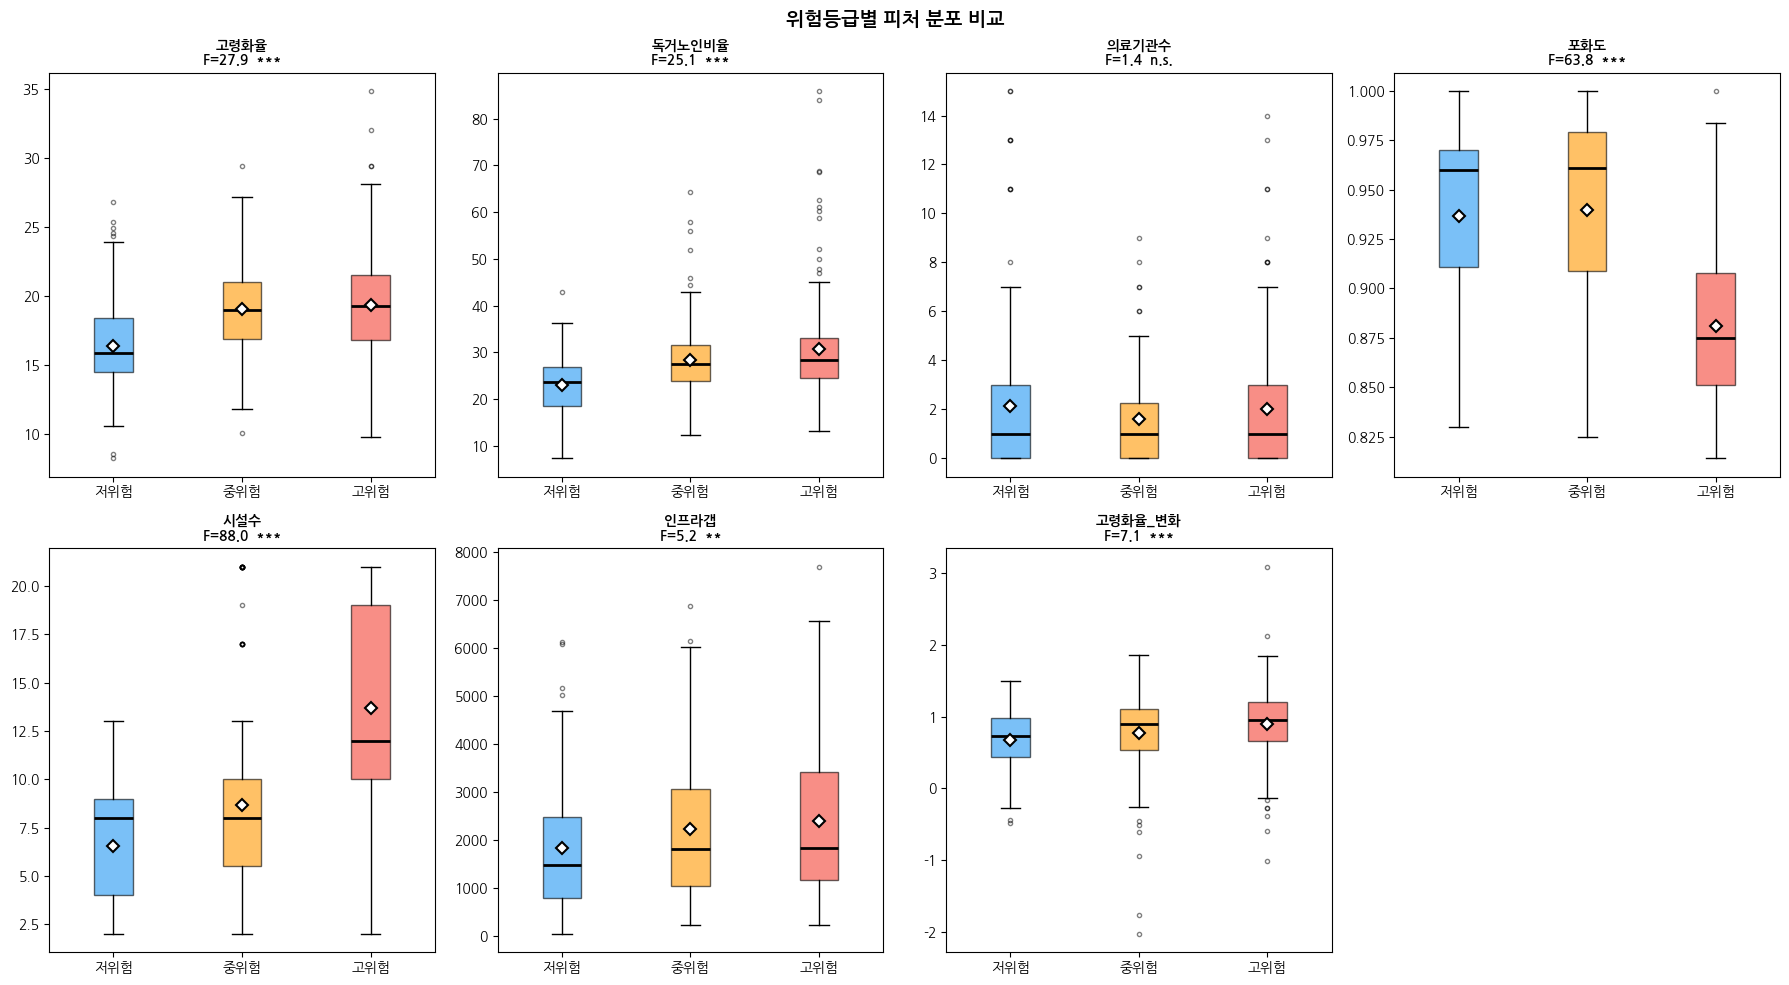

ANOVA 검정 결과  |  *** p<0.001  ** p<0.01  * p<0.05  n.s. 유의하지 않음
-----------------------------------------------------------------
피처                   F값       p값     유의성  해석
-----------------------------------------------------------------
고령화율               27.9   0.0000     ***  유효
독거노인비율             25.1   0.0000     ***  유효
의료기관수               1.4   0.2367    n.s.  기여 낮음
포화도                63.8   0.0000     ***  핵심 피처
시설수                88.0   0.0000     ***  핵심 피처
인프라갭                5.2   0.0059      **  유효
고령화율_변화             7.1   0.0010     ***  유효

클래스별 피처 평균값
       고령화율  독거노인비율  의료기관수   포화도    시설수     인프라갭  고령화율_변화
위험등급                                                     
저위험   16.38   23.02   2.12  0.94   6.55  1825.83     0.68
중위험   19.05   28.37   1.61  0.94   8.65  2230.62     0.78
고위험   19.31   30.64   2.01  0.88  13.69  2385.44     0.90


In [ ]:
# =============================================================
# 위험등급별 피처 분포 비교 + ANOVA 통계 검정
# =============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('위험등급별 피처 분포 비교', fontsize=14, fontweight='bold')

colors_class = {'저위험':'#2196F3', '중위험':'#FF9800', '고위험':'#F44336'}
order        = ['저위험', '중위험', '고위험']

for i, feat in enumerate(FEATURES):
    ax = axes[i // 4][i % 4]
    data_by_class = [merged[merged['위험등급'] == c][feat].dropna().values for c in order]

    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))

    for patch, c in zip(bp['boxes'], order):
        patch.set_facecolor(colors_class[c])
        patch.set_alpha(0.6)

    # 클래스별 평균값 (다이아몬드 마커)
    for j, c in enumerate(order):
        mean = merged[merged['위험등급'] == c][feat].mean()
        ax.plot(j+1, mean, 'D', color='white', markersize=6,
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)

    # ANOVA p값을 서브타이틀에 표시
    fv, pv = stats.f_oneway(*data_by_class)
    sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else 'n.s.'))
    ax.set_title(f'{feat}\nF={fv:.1f}  {sig}', fontsize=10, fontweight='bold')
    ax.set_xticklabels(order)

# 빈 서브플롯 숨기기
axes[1][3].set_visible(False)

plt.tight_layout()
plt.show()

# ANOVA 수치 요약
print("ANOVA 검정 결과  |  *** p<0.001  ** p<0.01  * p<0.05  n.s. 유의하지 않음")
print("-" * 65)
print(f"{'피처':<15} {'F값':>7} {'p값':>8}  {'유의성':>6}  {'해석'}")
print("-" * 65)
for feat in FEATURES:
    groups = [merged[merged['위험등급']==c][feat].dropna() for c in order]
    fv, pv = stats.f_oneway(*groups)
    sig    = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else 'n.s.'))
    note   = "핵심 피처" if fv > 50 else ("유효" if pv < 0.05 else "기여 낮음")
    print(f"{feat:<15} {fv:>7.1f} {pv:>8.4f}  {sig:>6}  {note}")

print()
print("클래스별 피처 평균값")
print(merged.groupby('위험등급')[FEATURES].mean().round(2).loc[order].to_string())

## 6. 지역별 분포 분석

공간적 패턴을 파악해 고위험이 특정 자치구에 집중되는지 확인한다.
자치구별 고위험 집중도는 모델 결과 해석 및 정책 제언의 근거가 된다.
IMD_score 기준 고위험 TOP 10은 즉시 개입이 필요한 행정동 목록이다.

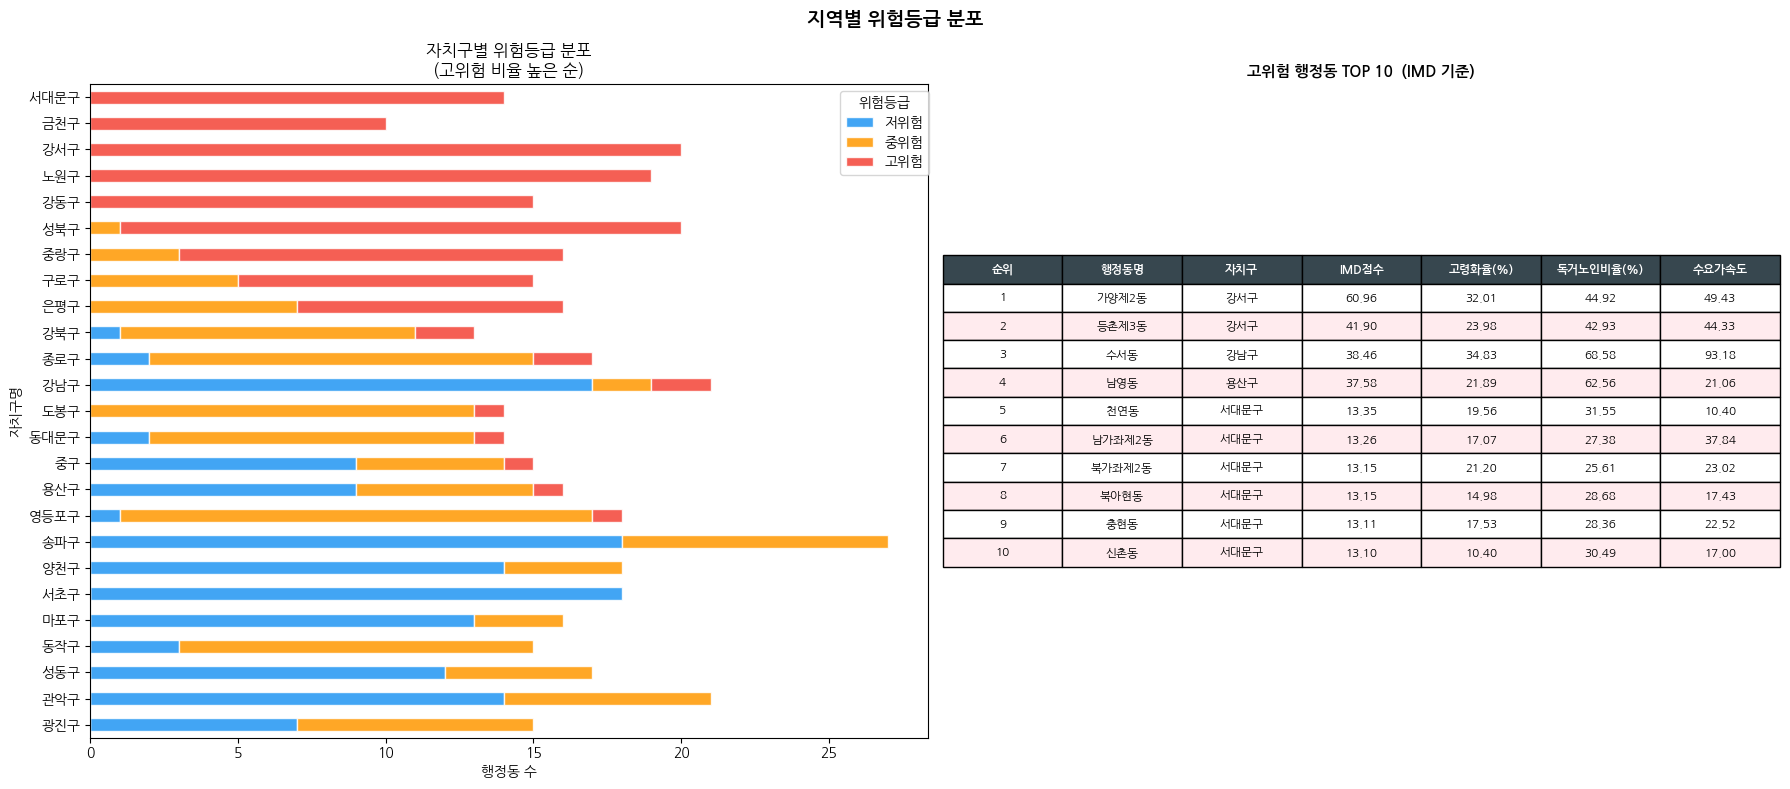

자치구별 고위험 행정동 비율 (상위 10개)
-----------------------------------
자치구명
강동구     100.0
금천구     100.0
강서구     100.0
노원구     100.0
서대문구    100.0
성북구      95.0
중랑구      81.2
구로구      66.7
은평구      56.2
강북구      15.4


In [ ]:
# =============================================================
# 자치구별 위험등급 분포 + 고위험 행정동 TOP 10
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('지역별 위험등급 분포', fontsize=14, fontweight='bold')

# 자치구별 누적 막대 (고위험 비율 기준 정렬)
gu_class = (merged.groupby(['자치구명', '위험등급'])
                  .size()
                  .unstack(fill_value=0))
for c in order:
    if c not in gu_class.columns:
        gu_class[c] = 0
gu_class = gu_class[order]
gu_class['고위험비율'] = gu_class['고위험'] / gu_class.sum(axis=1)
gu_class = gu_class.sort_values('고위험비율').drop(columns='고위험비율')

gu_class.plot(kind='barh', stacked=True, ax=axes[0],
              color=['#2196F3', '#FF9800', '#F44336'],
              alpha=0.85, edgecolor='white')
axes[0].set_title('자치구별 위험등급 분포\n(고위험 비율 높은 순)')
axes[0].set_xlabel('행정동 수')
axes[0].legend(title='위험등급', bbox_to_anchor=(1.01, 1))

# 고위험 행정동 TOP 10 (IMD_score 기준)
top10 = (merged[merged['위험등급'] == '고위험']
         [['행정동명', '자치구명', 'IMD_score', '고령화율', '독거노인비율', '요양수요가속도']]
         .sort_values('IMD_score', ascending=False)
         .head(10)
         .reset_index(drop=True))
top10.index += 1

axes[1].axis('off')
col_labels = ['행정동명', '자치구', 'IMD점수', '고령화율(%)', '독거노인비율(%)', '수요가속도']
tbl = axes[1].table(
    cellText=[[str(i+1)] + [f'{v:.2f}' if isinstance(v, float) else str(v)
                             for v in row]
              for i, row in enumerate(top10.values.tolist())],
    colLabels=['순위'] + col_labels,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.6)
for j in range(len(col_labels)+1):
    tbl[0, j].set_facecolor('#37474F')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, 11):
    for j in range(len(col_labels)+1):
        tbl[i, j].set_facecolor('#FFEBEE' if i % 2 == 0 else 'white')
axes[1].set_title('고위험 행정동 TOP 10  (IMD 기준)',
                  fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 자치구별 고위험 비율 수치 출력
print("자치구별 고위험 행정동 비율 (상위 10개)")
print("-" * 35)
gu_rate = (merged.groupby(['자치구명','위험등급'])
                 .size().unstack(fill_value=0))
gu_rate['고위험비율(%)'] = (gu_rate.get('고위험', 0) / gu_rate.sum(axis=1) * 100).round(1)
print(gu_rate['고위험비율(%)'].sort_values(ascending=False).head(10).to_string())

## 7. EDA 종합 요약 및 전처리 계획

EDA 전 과정에서 발견한 내용을 기반으로 모델링 전 전처리 방향을 확정한다.

In [ ]:
# =============================================================
# 피처별 종합 현황 테이블 + 전처리 계획 출력
# =============================================================

# 피처별 지표 통합
vif_data = merged[FEATURES].dropna()
vif_vals = {f: variance_inflation_factor(vif_data.values, i)
            for i, f in enumerate(FEATURES)}
corr_y   = merged[FEATURES + ['위험등급_num']].corr()['위험등급_num'].drop('위험등급_num')
anova_f  = {}
for feat in FEATURES:
    groups = [merged[merged['위험등급']==c][feat].dropna() for c in order]
    fv, pv = stats.f_oneway(*groups)
    anova_f[feat] = {'F': round(fv,1), 'p': round(pv,4)}
outlier_n = {}
for feat in FEATURES:
    Q1, Q3 = merged[feat].quantile(0.25), merged[feat].quantile(0.75)
    IQR    = Q3 - Q1
    outlier_n[feat] = int(((merged[feat] < Q1-1.5*IQR) |
                           (merged[feat] > Q3+1.5*IQR)).sum())

summary = pd.DataFrame({
    'Y_상관(r)'  : {f: round(corr_y[f], 3) for f in FEATURES},
    'ANOVA_F'   : {f: anova_f[f]['F']      for f in FEATURES},
    'p값'       : {f: anova_f[f]['p']      for f in FEATURES},
    'VIF'       : {f: round(vif_vals[f],1) for f in FEATURES},
    '왜도'      : {f: round(merged[f].skew(),2) for f in FEATURES},
    '이상값수'  : outlier_n
}).sort_values('ANOVA_F', ascending=False)
summary['로그변환'] = summary['왜도'].apply(lambda x: '권장' if abs(x)>1.0 else '-')
summary['VIF판정']  = summary['VIF'].apply(
    lambda x: '제거검토' if x>10 else ('주의' if x>5 else 'OK'))

print("[ 피처별 종합 현황 ]")
print("=" * 75)
print(summary.to_string())

print()
print("=" * 55)
print("EDA 종합 요약")
print("=" * 55)
print("""
[1] Y 라벨 (IMD 기반 위험등급)
    고위험·중위험·저위험 각 140개 → 완벽한 균형
    → SMOTE 등 오버샘플링 불필요
    → 고위험 IMD_score 이상값 26개 존재하나
      3분위 기반 라벨링이므로 분류 결과 왜곡 없음

[2] 핵심 피처 (분류 성능 주도)
    시설수     F=88.0  r=+0.530  ← 1순위
    포화도     F=63.8  r=-0.406  ← 2순위
    고령화율   F=27.9  r=+0.310  ← 3순위
    독거노인비율 F=25.1 r=+0.319  ← 4순위

[3] 보조 피처 (모델 학습 후 중요도 재확인)
    고령화율_변화   F=7.1   p=0.001
    인프라갭       F=5.2   p=0.006
    연령가중수요지수 F=4.6  p=0.011

[4] 유의하지 않은 피처
    의료기관수  F=1.4  p=0.237  → 모델 학습 후 제거 검토

[5] 다중공선성
    포화도 VIF=416, 고령화율(VIF=38.2), 독거노인비율(VIF=11.4)
    → VIF 기준 제거 권장이나 ANOVA F값 각각 27.9, 25.1로 핵심 피처
    → 단순 제거가 아닌 전처리(로그변환, 스케일링) 후 VIF 재계산 필요
    포화도(VIF=24.5)
    → 시설수와 구조적 연동 → 전처리 단계에서 처리 방향 결정

[6] 전처리 단계에서 처리할 것
    로그변환  : 독거노인비율(skew=2.00), 의료기관수(skew=2.40)
               인프라갭(skew=1.01) → 전후 비교 후 결정
    스케일러  : RobustScaler 우선 검토 (이상값 多)
    피처 제거 : 연령가중수요지수 (VIF=522)

[7] 모델링 순서 (프로젝트 계획 기준)
    Logistic Regression → SVM(RBF) →
    Random Forest → XGBoost Classifier
    평가: Macro F1 / Precision / Recall / ROC-AUC / Confusion Matrix
    교차검증: StratifiedKFold (5-fold)
""")

[ 피처별 종합 현황 ]
         Y_상관(r)  ANOVA_F      p값   VIF    왜도  이상값수 로그변환 VIF판정
시설수        0.530     88.0  0.0000   4.4  0.59     0    -    OK
포화도       -0.406     63.8  0.0000  24.5 -0.39     0    -  제거검토
고령화율       0.310     27.9  0.0000  38.2  0.42     5    -  제거검토
독거노인비율     0.319     25.1  0.0000  11.4  2.00    21   권장  제거검토
고령화율_변화    0.181      7.1  0.0010   4.9 -0.99    13    -    OK
인프라갭       0.151      5.2  0.0059   5.1  1.01    11   권장    주의
의료기관수     -0.018      1.4  0.2367   2.3  2.40    19   권장    OK

EDA 종합 요약

[1] Y 라벨 (IMD 기반 위험등급)
    고위험·중위험·저위험 각 140개 → 완벽한 균형
    → SMOTE 등 오버샘플링 불필요
    → 고위험 IMD_score 이상값 26개 존재하나
      3분위 기반 라벨링이므로 분류 결과 왜곡 없음

[2] 핵심 피처 (분류 성능 주도)
    시설수     F=88.0  r=+0.530  ← 1순위
    포화도     F=63.8  r=-0.406  ← 2순위
    고령화율   F=27.9  r=+0.310  ← 3순위
    독거노인비율 F=25.1 r=+0.319  ← 4순위

[3] 보조 피처 (모델 학습 후 중요도 재확인)
    고령화율_변화   F=7.1   p=0.001
    인프라갭       F=5.2   p=0.006
    연령가중수요지수 F=4.6  p=0.011

[4] 유의하지 않은 피처
    의료기관수  F=1.4  p=0.237  → 